<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/TFRegressionNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/kaledev/PythonSnippets/refs/heads/master/Datasets/Keras/fake_reg.csv")

df.head(1)

,price,feature1,feature2
0,461.527929,999.787558,999.766096


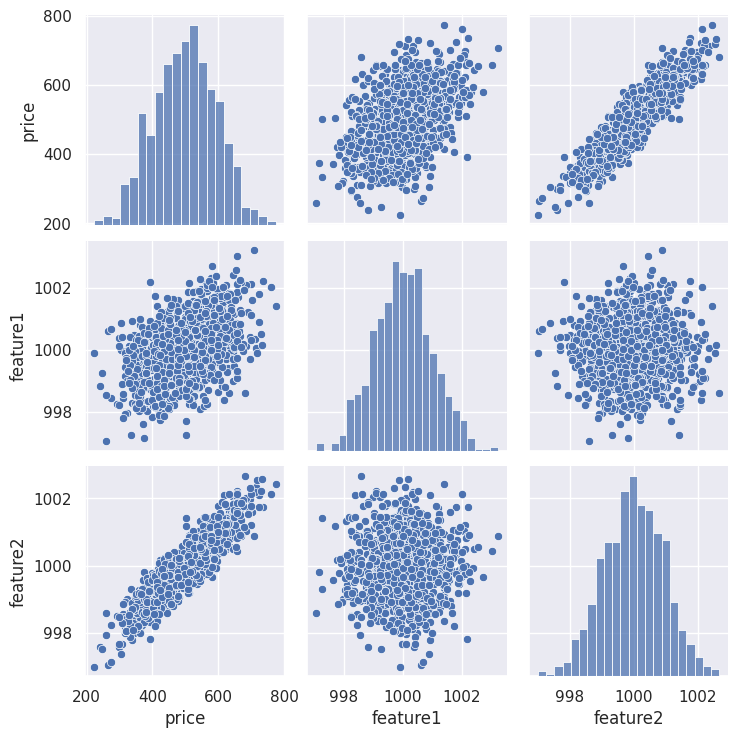

In [3]:
sns.pairplot(df)

In [4]:
from sklearn.model_selection import train_test_split

X = df[['feature1', 'feature2']].values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((670, 2), (330, 2), (670,), (330,))

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

<Axes: >

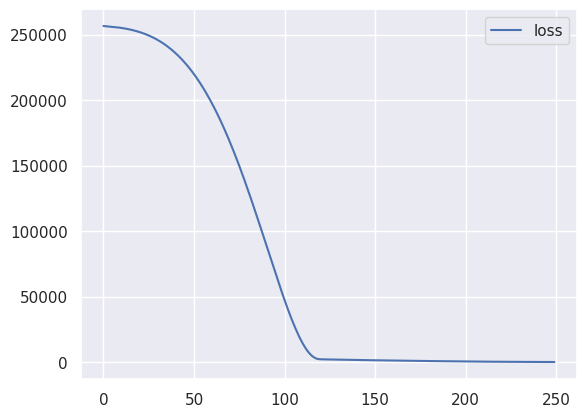

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='rmsprop', loss='mse')

model.fit(x=X_train, y=y_train, epochs=250, verbose=0)

pd.DataFrame(model.history.history).plot()

In [7]:
model.evaluate(X_test, y_test, verbose=0), model.evaluate(X_train, y_train, verbose=0)

(46.969417572021484, 47.752376556396484)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


<Axes: xlabel='Test Y', ylabel='Model Predictions'>

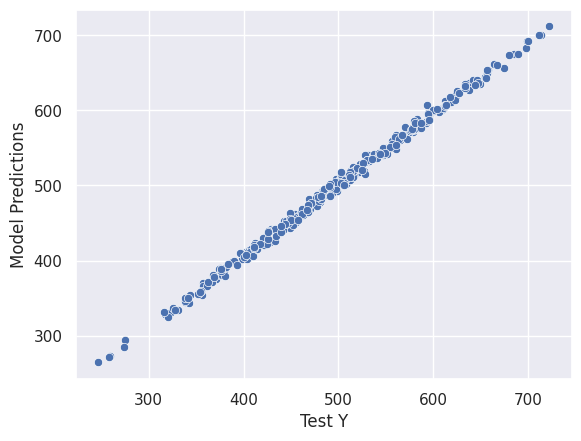

In [8]:
predictions = model.predict(X_test)

predictions = pd.Series(predictions.reshape(330, ))

y_test_df = pd.DataFrame(y_test, columns=['Test Y'])

predictions_df = pd.concat([y_test_df, predictions], axis=1)
predictions_df.columns = ['Test Y', 'Model Predictions']

sns.scatterplot(data=predictions_df, x='Test Y', y='Model Predictions')

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error(predictions_df['Test Y'], predictions_df['Model Predictions']), mean_squared_error(predictions_df['Test Y'], predictions_df['Model Predictions'])

(5.589249986065733, 46.96942469247823)

In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/Shreyas3108/house-price-prediction/refs/heads/master/kc_house_data.csv")

df.head(1)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.0,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650


In [11]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


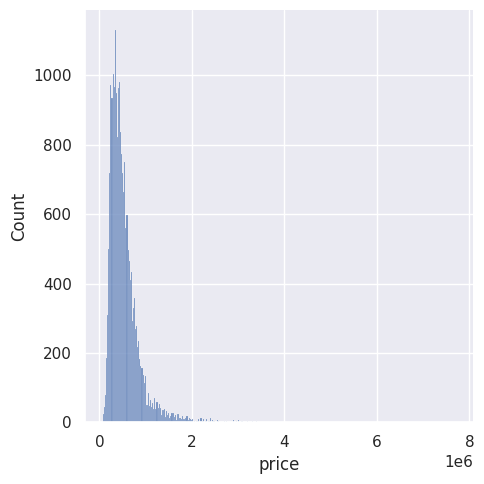

In [12]:
sns.displot(df['price'])

In [13]:
df.corr(numeric_only=True)['price'].sort_values()

,price
zipcode,-0.053203
id,-0.016762
long,0.021626
condition,0.036362
yr_built,0.054012
sqft_lot15,0.082447
sqft_lot,0.089661
yr_renovated,0.126434
floors,0.256794
waterfront,0.266369


<Axes: xlabel='price', ylabel='sqft_living'>

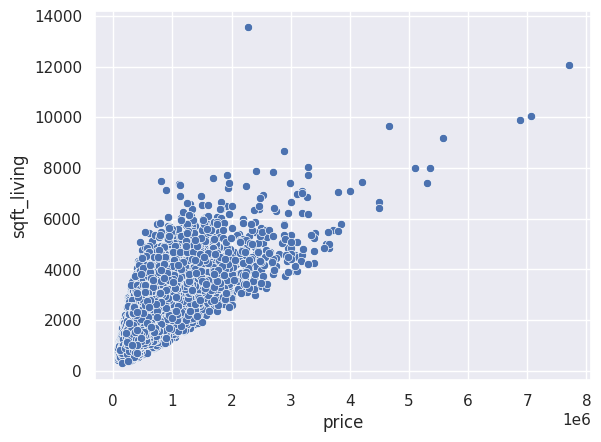

In [14]:
sns.scatterplot(x=df['price'], y=df['sqft_living'])

<Axes: xlabel='long', ylabel='lat'>

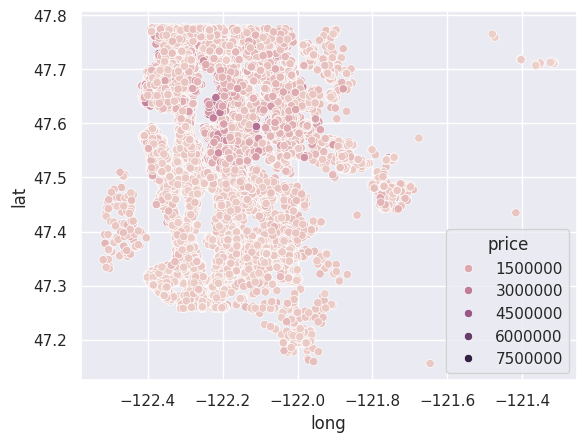

In [15]:
sns.scatterplot(x=df['long'], y=df['lat'], hue=df['price'])

In [16]:
non_top_1_percent = df.sort_values('price', ascending=False).iloc[216:]

In [17]:
len(df)*0.01

216.13

<Axes: xlabel='long', ylabel='lat'>

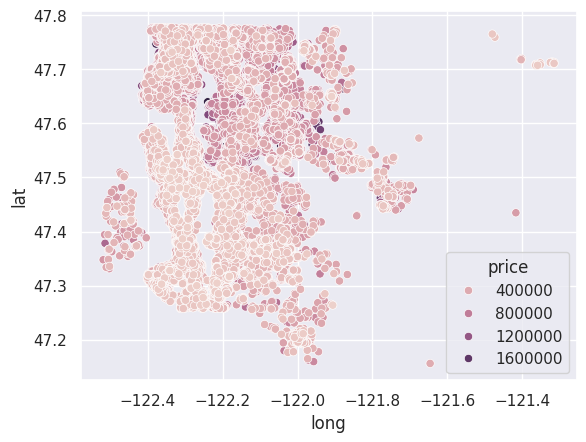

In [18]:
sns.scatterplot(x=non_top_1_percent['long'], y=non_top_1_percent['lat'], hue=non_top_1_percent['price'])

<Axes: xlabel='long', ylabel='lat'>

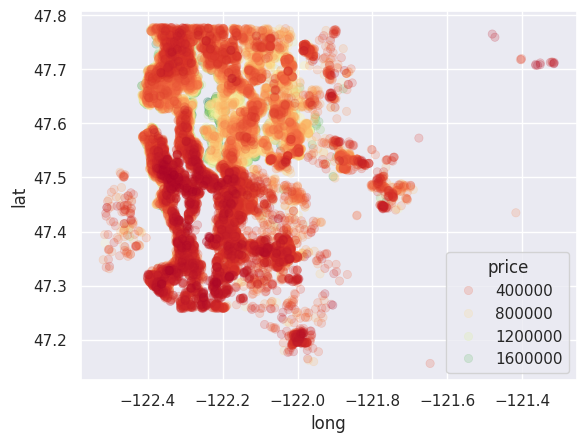

In [19]:
sns.scatterplot(x=non_top_1_percent['long'], y=non_top_1_percent['lat'], hue=non_top_1_percent['price'], edgecolor=None, alpha=0.2, palette='RdYlGn')

<Axes: xlabel='waterfront', ylabel='price'>

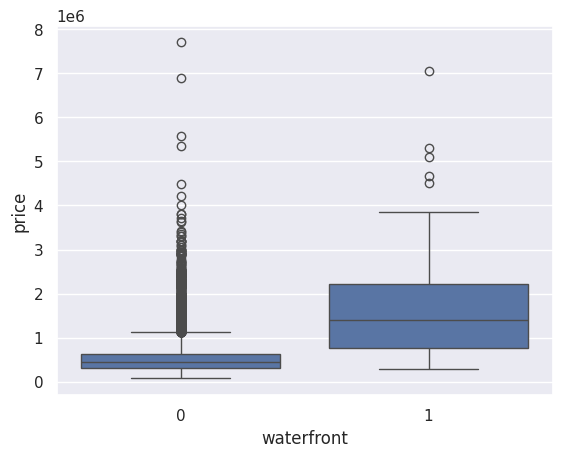

In [20]:
sns.boxplot(x=df['waterfront'], y=df['price'])

In [21]:
df = df.drop('id', axis=1)

In [22]:
df['date'] = pd.to_datetime(df['date'])

In [23]:
df['year'] = df['date'].apply(lambda date: date.year)
df['month'] = df['date'].apply(lambda date: date.month)

In [24]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,2014-10-13,221900.0,3,1.0,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10


<Axes: xlabel='month', ylabel='price'>

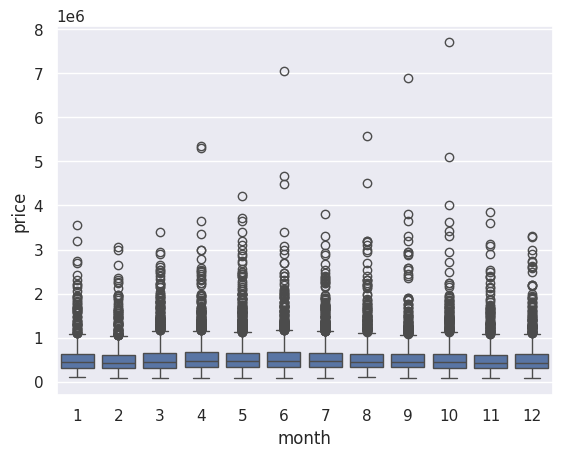

In [25]:
sns.boxplot(x=df['month'], y=df['price'])

In [26]:
df.groupby('month').mean()['price']

,price
month,
1,525870.889571
2,507851.371200
3,543977.187200
4,561837.774989
5,550768.785833
6,558002.199541
7,544788.764360
8,536445.276804
9,529253.821871


<Axes: xlabel='month'>

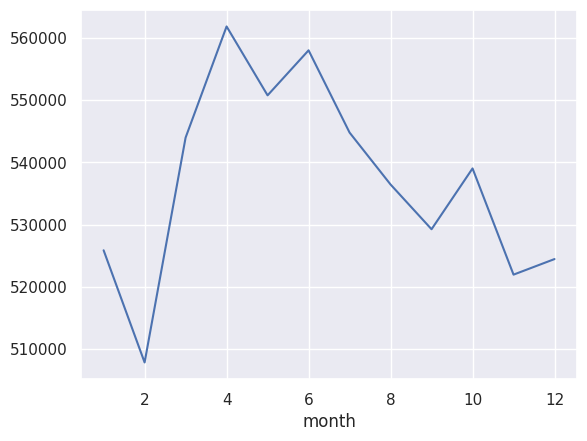

In [27]:
df.groupby('month').mean()['price'].plot()

<Axes: xlabel='year'>

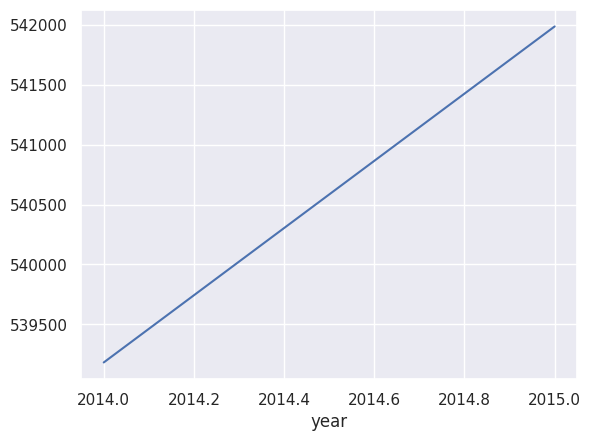

In [28]:
df.groupby('year').mean()['price'].plot()

In [29]:
df = df.drop('date', axis=1)

In [30]:
df = df.drop('zipcode', axis=1)

<Axes: >

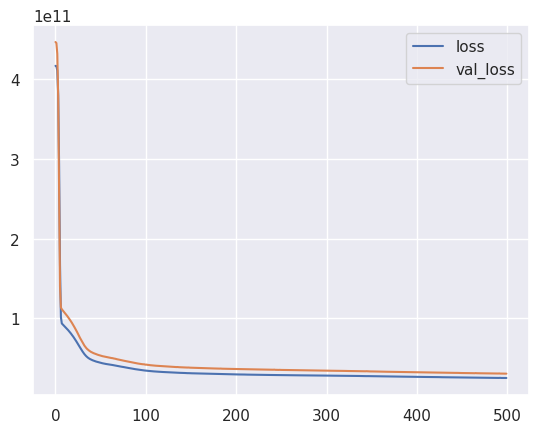

In [31]:
X = df.drop('price', axis=1).values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train.shape # (14480, 19)

model = Sequential()

model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(x=X_train, y=y_train,
          validation_data=(X_test, y_test),
          batch_size=128,
          epochs=500, verbose=0)

pd.DataFrame(model.history.history).plot()

223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
0.7939277268523471


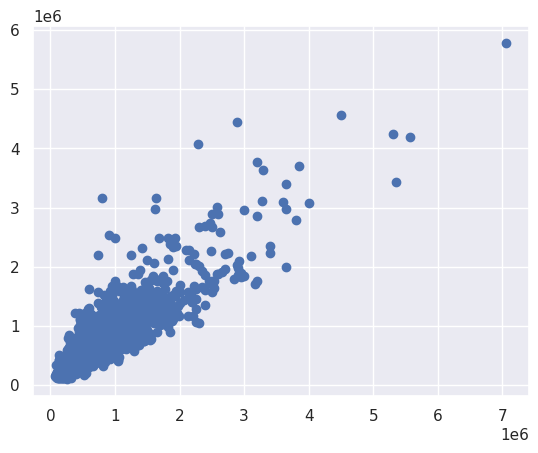

In [32]:
predictions = model.predict(X_test)

from sklearn.metrics import explained_variance_score

print(explained_variance_score(y_test, predictions))

plt.scatter(y_test, predictions)